In [ ]:
!git clone -b week4/deepfake https://github.com/eth-bmai-fs26/project.git

In [1]:
# imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, shutil, random
from PIL import Image

import sys, glob
# Auto-find utils.py — works from repo root, notebook dir, or /content
for _base in [os.getcwd(), '/content']:
    for _match in glob.glob(os.path.join(_base, '**', 'utils.py'), recursive=True):
        if 'deepfake' in _match:
            sys.path.insert(0, os.path.dirname(_match))
            break

from utils import (
    SEED, IMG_SIZE, prepare_fruit_dataset, load_fruit_data,
    create_mask_and_crop_batch, visualize_masking,
    show_batch, find_samples_per_class,
)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


### 0.1 Download the Fruit Dataset

We use a subset of the **Fruits-360** dataset, keeping only apples and oranges.
The images are 100×100 RGB — we'll resize to 64×64 for faster training.

In [2]:
# download & prepare dataset

!pip install -q kagglehub
import kagglehub
dataset_path = kagglehub.dataset_download("moltean/fruits")

Using Colab cache for faster access to the 'fruits' dataset.


In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download("moltean/fruits")
print(f"Dataset downloaded to: {dataset_path}")

# Show apple/orange directories
import subprocess
result = subprocess.run(['find', dataset_path, '-maxdepth', '3', '-type', 'd'],
                       capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if any(fruit in line.lower() for fruit in ['apple', 'orange', 'training', 'test']):
        print(line)

Using Colab cache for faster access to the 'fruits' dataset.
Dataset downloaded to: /kaggle/input/fruits
/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
/kaggle/input/fruits/fruits-360_100x100/fruits-360/Test
/kaggle/input/fruits/fruits-360_3-body-problem/fruits-360-3-body-problem/Training
/kaggle/input/fruits/fruits-360_3-body-problem/fruits-360-3-body-problem/Test
/kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size/Training
/kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size/Test
/kaggle/input/fruits/fruits-360_multi/test-multiple_fruits


In [4]:
# Prepare dataset using shared utility
DATA_ROOT = prepare_fruit_dataset(dataset_path, balance=True)

  ✅ train: 'Apple 10' → apple
  ✅ train: 'Apple 11' → apple
  ✅ train: 'Apple 12' → apple
  ✅ train: 'Apple 13' → apple
  ✅ train: 'Apple 14' → apple
  ✅ train: 'Apple 17' → apple
  ✅ train: 'Apple 18' → apple
  ✅ train: 'Apple 19' → apple
  ✅ train: 'Apple 20' → apple
  ✅ train: 'Apple 21' → apple
  ✅ train: 'Apple 22' → apple
  ✅ train: 'Apple 23' → apple
  ✅ train: 'Apple 5' → apple
  ✅ train: 'Apple 6' → apple
  ✅ train: 'Apple 7' → apple
  ✅ train: 'Apple 8' → apple
  ✅ train: 'Apple 9' → apple
  ✅ train: 'Apple Braeburn 1' → apple
  ✅ train: 'Apple Crimson Snow 1' → apple
  ✅ train: 'Apple Golden 1' → apple
  ✅ train: 'Apple Golden 2' → apple
  ✅ train: 'Apple Golden 3' → apple
  ✅ train: 'Apple Granny Smith 1' → apple
  ✅ train: 'Apple Pink Lady 1' → apple
  ✅ train: 'Apple Red 1' → apple
  ✅ train: 'Apple Red 2' → apple
  ✅ train: 'Apple Red 3' → apple
  ✅ train: 'Apple Red Delicious 1' → apple
  ✅ train: 'Apple Red Yellow 1' → apple
  ✅ train: 'Apple Red Yellow 2' → apple
  ✅ 

In [ ]:
# Pipeline constants (IMG_SIZE and SEED imported from utils)
BATCH_SIZE = 512
NUM_EPOCHS = 120
LEARNING_RATE = 2e-4
NUM_TIMESTEPS = 500
EMBED_DIM = 128
BASE_CHANNELS = 64

In [6]:
# Data transforms and loading
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=transform)
test_dataset  = ImageFolder(os.path.join(DATA_ROOT, 'test'),  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = {v: k for k, v in train_dataset.class_to_idx.items()}
print(f"Classes: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Classes: {0: 'apple', 1: 'orange'}
Train: 3794, Test: 1256
Index → Name: {0: 'apple', 1: 'orange'}


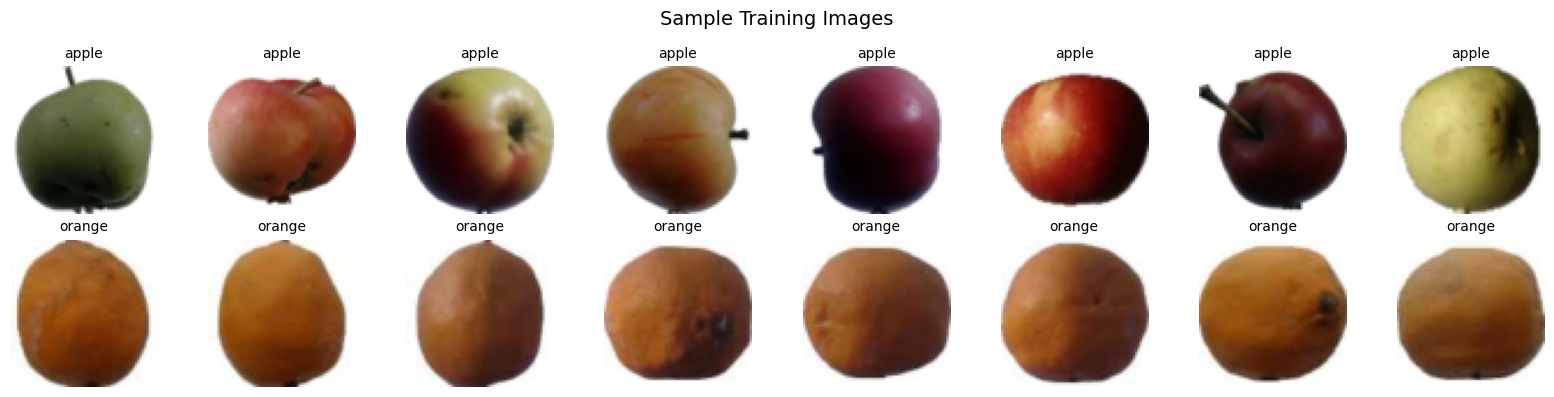

In [26]:
show_batch(train_loader, CLASS_NAMES)

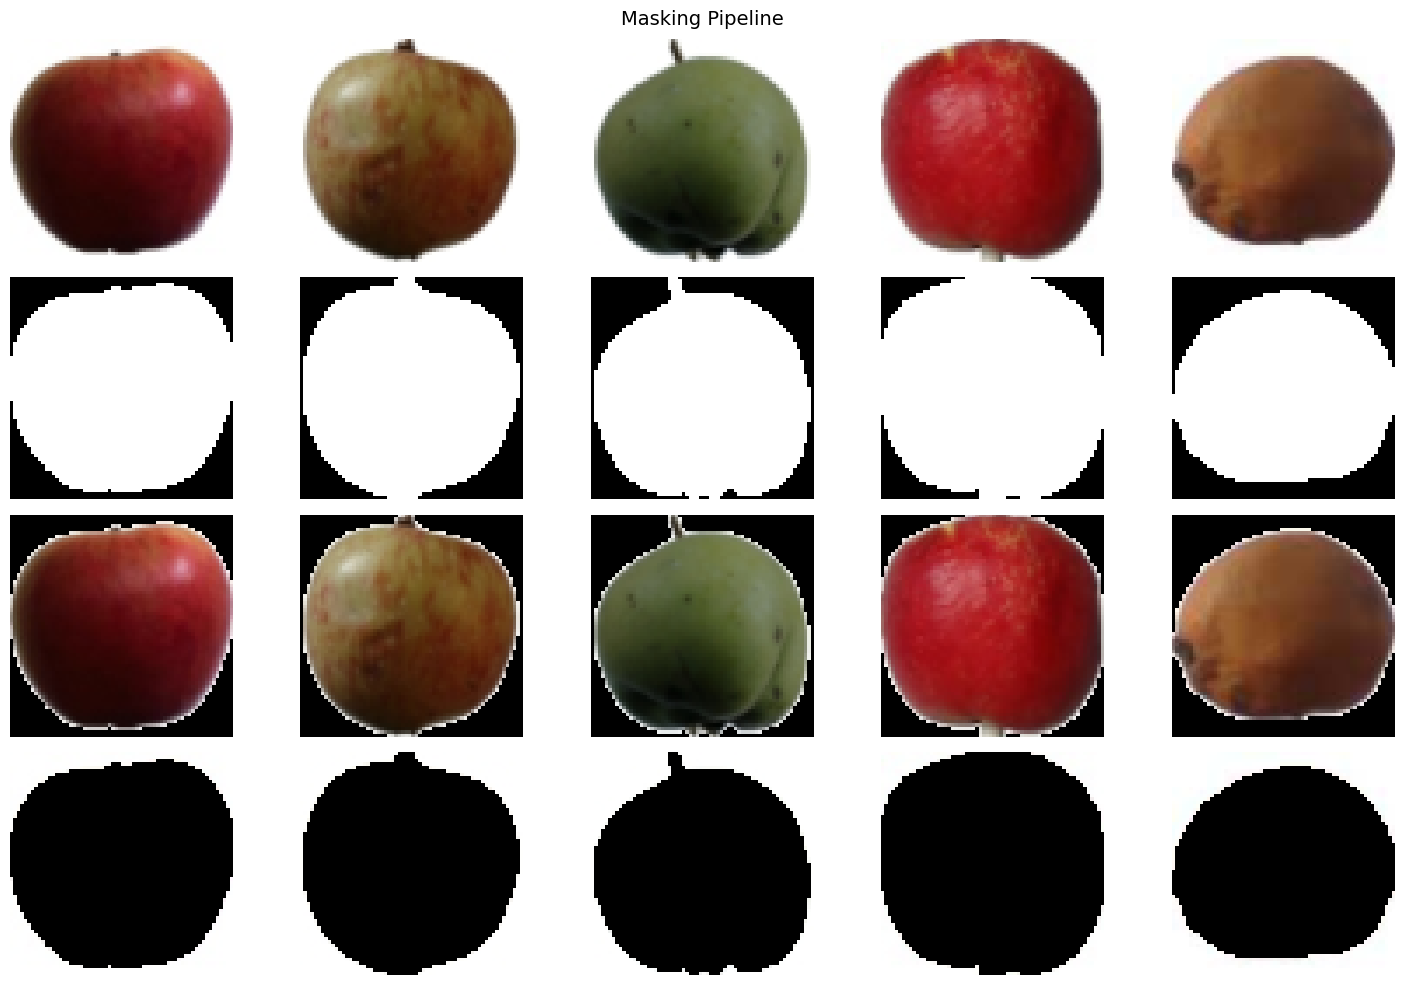

In [8]:
# Test masking (function imported from utils)
sample_imgs, _ = next(iter(train_loader))
visualize_masking(sample_imgs)

In [9]:
# === CELL 5: Fruit Encoder (Phase 2) ===

class FruitEncoder(nn.Module):
    """
    Encodes a cropped fruit image into a conditioning embedding.
    This embedding tells the diffusion U-Net WHICH fruit to generate.
    Trained jointly with the U-Net.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),  nn.GroupNorm(8, 32),  nn.GELU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.GroupNorm(8, 64),  nn.GELU(),
            nn.Conv2d(64, 128, 3, 2, 1),nn.GroupNorm(8, 128), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, embed_dim),
        )

    def forward(self, x):
        return self.net(x)  # (B, embed_dim)

# Quick test
enc = FruitEncoder().to(device)
dummy = torch.randn(4, 3, 64, 64).to(device)
print(f"Encoder output shape: {enc(dummy).shape}")  # should be (4, 128)

Encoder output shape: torch.Size([4, 128])


In [10]:
# === CELL 6: Building Blocks for U-Net ===

class SinusoidalPosEmb(nn.Module):
    """Sinusoidal timestep embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = torch.log(torch.tensor(10000.0, device=t.device)) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ConvBlock(nn.Module):
    """Double conv with GroupNorm and GELU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1),
            nn.GroupNorm(8, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1),
            nn.GroupNorm(8, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)

In [11]:
class CrossAttention(nn.Module):
    """
    Cross-attention conditioning for the U-Net.

    The U-Net features (Q) attend to the conditioning embedding (K, V).
    Each spatial location in the feature map asks: "given this fruit
    embedding, what should I generate here?"

    The conditioning vector is projected into num_tokens synthetic tokens
    so the attention has multiple key-value pairs to attend to.
    """
    def __init__(self, feature_dim, embed_dim=EMBED_DIM, num_heads=4, num_tokens=4):
        super().__init__()
        self.num_heads = num_heads
        self.num_tokens = num_tokens
        self.head_dim = feature_dim // num_heads
        self.scale = self.head_dim ** -0.5

        # Project conditioning embedding → K, V tokens
        # Single vector → (num_tokens, feature_dim) sequence
        self.to_kv_tokens = nn.Sequential(
            nn.Linear(embed_dim, feature_dim * num_tokens),
            nn.GELU(),
            nn.Linear(feature_dim * num_tokens, feature_dim * num_tokens * 2),
        )

        # Q comes from the U-Net feature map
        self.to_q = nn.Linear(feature_dim, feature_dim)

        # Output projection
        self.to_out = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.GELU(),
        )

        # Layer norm for stability
        self.norm_features = nn.LayerNorm(feature_dim)
        self.norm_out = nn.LayerNorm(feature_dim)

    def forward(self, x, cond):
        """
        x:    (B, C, H, W) — U-Net feature map
        cond: (B, embed_dim) — combined time + fruit embedding

        Returns: (B, C, H, W) — modulated feature map
        """
        B, C, H, W = x.shape
        residual = x

        # Reshape feature map to sequence: (B, H*W, C)
        x_flat = x.permute(0, 2, 3, 1).reshape(B, H * W, C)
        x_flat = self.norm_features(x_flat)

        # Q from features: (B, H*W, C)
        q = self.to_q(x_flat)

        # K, V from conditioning: (B, num_tokens, C) each
        kv = self.to_kv_tokens(cond)                          # (B, C * num_tokens * 2)
        kv = kv.reshape(B, self.num_tokens, 2, C)             # (B, num_tokens, 2, C)
        k, v = kv[:, :, 0], kv[:, :, 1]                      # each (B, num_tokens, C)

        # Reshape for multi-head attention
        # (B, num_heads, seq_len, head_dim)
        q = q.reshape(B, H * W, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        k = k.reshape(B, self.num_tokens, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        v = v.reshape(B, self.num_tokens, self.num_heads, self.head_dim).permute(0, 2, 1, 3)

        # Attention: (B, heads, H*W, num_tokens)
        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        # Apply attention to values: (B, heads, H*W, head_dim)
        out = torch.matmul(attn, v)

        # Reshape back: (B, H*W, C)
        out = out.permute(0, 2, 1, 3).reshape(B, H * W, C)
        out = self.to_out(out)
        out = self.norm_out(out)

        # Reshape to spatial + residual connection
        out = out.reshape(B, H, W, C).permute(0, 3, 1, 2)
        return residual + out

In [12]:
class ConditionedUNet(nn.Module):
    """
    U-Net for noise prediction in pixel-space diffusion.

    Spatial conditioning: redacted image (3ch) + mask (1ch) concatenated
                          with noisy image (3ch) → 7 input channels
    Semantic conditioning: fruit embedding
    Time conditioning:     sinusoidal embedding added to fruit embedding
    """
    def __init__(self, in_channels=7, out_channels=3,
                 base_ch=BASE_CHANNELS, embed_dim=EMBED_DIM):
        super().__init__()
        ch = base_ch  # 64

        # --- Time + condition embedding ---
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(ch),
            nn.Linear(ch, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )

        # --- Encoder ---
        self.enc1 = ConvBlock(in_channels, ch)        # 64 channels
        self.enc2 = ConvBlock(ch, ch * 2)             # 128
        self.enc3 = ConvBlock(ch * 2, ch * 4)         # 256

        self.down = nn.MaxPool2d(2)

        # --- Bottleneck ---
        self.bottleneck = ConvBlock(ch * 4, ch * 4)   # 256

        # --- Decoder ---
        self.up3 = nn.ConvTranspose2d(ch * 4, ch * 4, 2, 2)
        self.dec3 = ConvBlock(ch * 8, ch * 2)         # skip: 256+256=512 → 128

        self.up2 = nn.ConvTranspose2d(ch * 2, ch * 2, 2, 2)
        self.dec2 = ConvBlock(ch * 4, ch)             # skip: 128+128=256 → 64

        self.up1 = nn.ConvTranspose2d(ch, ch, 2, 2)
        self.dec1 = ConvBlock(ch * 2, ch)             # skip: 64+64=128 → 64

        self.out_conv = nn.Conv2d(ch, out_channels, 1)

        self.attn_enc3 = CrossAttention(feature_dim=ch * 4, embed_dim=embed_dim)
        self.attn_bottleneck = CrossAttention(feature_dim=ch * 4, embed_dim=embed_dim)
        self.attn_dec2 = CrossAttention(feature_dim=ch, embed_dim=embed_dim)

    def forward(self, x_noisy, t, redacted, mask, fruit_embed):
        """
        x_noisy:     (B, 3, H, W)
        t:           (B,) timestep indices
        redacted:    (B, 3, H, W) background with fruit masked
        mask:        (B, 1, H, W) binary mask
        fruit_embed: (B, embed_dim) from FruitEncoder
        """
        # Combine time and fruit conditioning
        t_emb = self.time_mlp(t)             # (B, embed_dim)
        cond = t_emb + fruit_embed           # (B, embed_dim)

        # Spatial input: concat noisy image + redacted + mask
        x = torch.cat([x_noisy, redacted, mask], dim=1)  # (B, 7, H, W)

        # Encoder
        e1 = self.enc1(x)                    # (B, 64, 64, 64)
        e2 = self.enc2(self.down(e1))        # (B, 128, 32, 32)
        e3 = self.enc3(self.down(e2))        # (B, 256, 16, 16)
        e3 = self.attn_enc3(e3, cond)        # (B, 256, 16, 16)

        # Bottleneck
        b = self.bottleneck(self.down(e3))   # (B, 256, 8, 8)
        b = self.attn_bottleneck(b, cond)

        # Decoder + skip connections
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))   # (B, 128, 16, 16)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))  # (B, 64, 32, 32)
        d2 = self.attn_dec2(d2, cond)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))  # (B, 64, 64, 64)

        return self.out_conv(d1)  # (B, 3, 64, 64) predicted noise


# Smoke test
unet = ConditionedUNet().to(device)
total_params = sum(p.numel() for p in unet.parameters())
print(f"U-Net parameters: {total_params:,}")

dummy_noisy = torch.randn(2, 3, 64, 64).to(device)
dummy_t = torch.tensor([10, 200]).to(device)
dummy_redact = torch.randn(2, 3, 64, 64).to(device)
dummy_mask = torch.ones(2, 1, 64, 64).to(device)
dummy_emb = torch.randn(2, EMBED_DIM).to(device)

out = unet(dummy_noisy, dummy_t, dummy_redact, dummy_mask, dummy_emb)
print(f"U-Net output shape: {out.shape}")  # (2, 3, 64, 64)
print("U-Net test passed! ✅")

U-Net parameters: 8,634,947
U-Net output shape: torch.Size([2, 3, 64, 64])
U-Net test passed! ✅


In [13]:
# === CELL 8: DDPM Noise Scheduler ===

class DDPMScheduler:
    """
    Handles the forward (noising) and reverse (denoising) diffusion process.
    """
    def __init__(self, num_timesteps=NUM_TIMESTEPS,
                 beta_start=1e-4, beta_end=0.02, device='cuda'):
        self.num_timesteps = num_timesteps
        self.device = device

        betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

    def add_noise(self, x_0, t, noise=None):
        """q(x_t | x_0): add noise to clean image."""
        if noise is None:
            noise = torch.randn_like(x_0)

        sqrt_alpha = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_one_minus = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]

        x_t = sqrt_alpha * x_0 + sqrt_one_minus * noise
        return x_t, noise

    @torch.no_grad()
    def sample_step(self, model, x_t, t_val, redacted, mask, fruit_embed):
        """Single reverse step: x_t → x_{t-1}"""
        B = x_t.shape[0]
        t = torch.full((B,), t_val, device=self.device, dtype=torch.long)

        pred_noise = model(x_t, t, redacted, mask, fruit_embed)

        alpha_t = self.alphas[t_val]
        alpha_bar_t = self.alphas_cumprod[t_val]
        beta_t = self.betas[t_val]

        coeff = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        mean = (1 / torch.sqrt(alpha_t)) * (x_t - coeff * pred_noise)

        if t_val > 0:
            noise = torch.randn_like(x_t)
            x_t = mean + torch.sqrt(beta_t) * noise
        else:
            x_t = mean

        return x_t

    @torch.no_grad()
    def sample(self, model, fruit_encoder, crop, redacted, mask,
               return_intermediates=False, intermediate_steps=10):
        """
        Full reverse process: z_T → z_0

        If return_intermediates=True, saves snapshots every N steps
        for visualization of the denoising progression.
        """
        shape = redacted.shape
        x = torch.randn(shape, device=self.device)

        fruit_embed = fruit_encoder(crop)

        intermediates = []
        save_every = self.num_timesteps // intermediate_steps

        for t_val in reversed(range(self.num_timesteps)):
            x = self.sample_step(model, x, t_val, redacted, mask, fruit_embed)

            if return_intermediates and (t_val % save_every == 0 or t_val == 0):
                intermediates.append(x.cpu().clone())

        if return_intermediates:
            return x, intermediates
        return x

In [14]:
# === CELL 9: Training Loop ===

def train_diffusion(unet, fruit_encoder, scheduler, train_loader,
                    device, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
                    swap_prob=0.5):
    """
    Train U-Net and FruitEncoder jointly.

    swap_prob: probability of swapping the conditioning to a different
    class's crop during training. This forces the model to actually
    USE the conditioning embedding rather than just copying textures.
    """
    optimizer = optim.Adam(
        list(unet.parameters()) + list(fruit_encoder.parameters()), lr=lr
    )
    scheduler_lr = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = []

    for epoch in range(1, num_epochs + 1):
        unet.train()
        fruit_encoder.train()
        epoch_loss = 0
        n_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            B = images.size(0)

            # Phase 1: mask all images
            masks, crops, redacted = create_mask_and_crop_batch(images)

            # Phase 2: decide which samples get swapped conditioning
            # For swapped samples, we need to:
            #   - use a DIFFERENT fruit's crop as conditioning
            #   - use that DIFFERENT fruit's FULL image as the denoising target
            swap_mask = torch.rand(B, device=device) < swap_prob

            # Find indices of each class in the batch
            class_0_idx = (labels == 0).nonzero(as_tuple=True)[0]
            class_1_idx = (labels == 1).nonzero(as_tuple=True)[0]

            # Skip if batch doesn't have both classes (can't swap)
            if len(class_0_idx) == 0 or len(class_1_idx) == 0:
                # Fall back to normal training (no swap)
                fruit_embed = fruit_encoder(crops)
                t = torch.randint(0, scheduler.num_timesteps, (B,), device=device)
                noise = torch.randn_like(images)
                x_noisy, _ = scheduler.add_noise(images, t, noise)
                pred_noise = unet(x_noisy, t, redacted, masks, fruit_embed)
                loss = F.mse_loss(pred_noise, noise)
            else:
                # Build the conditioning crops and target images
                cond_crops = crops.clone()
                target_images = images.clone()
                target_redacted = redacted.clone()
                target_masks = masks.clone()

                for i in range(B):
                    if swap_mask[i]:
                        # Pick a random sample from the OPPOSITE class
                        if labels[i] == 0:
                            donor_idx = class_1_idx[torch.randint(len(class_1_idx), (1,))]
                        else:
                            donor_idx = class_0_idx[torch.randint(len(class_0_idx), (1,))]

                        # Conditioning comes from the donor's crop
                        cond_crops[i] = crops[donor_idx]

                        # Target becomes the donor's full image
                        # (because we want the model to generate what
                        #  matches the conditioning, not the original)
                        target_images[i] = images[donor_idx]

                        # Redacted and mask come from the ORIGINAL image
                        # (we keep the original background/mask layout)
                        # For Fruits-360 this doesn't matter much since
                        # backgrounds are all white, but architecturally
                        # it's correct: "same scene, different fruit"

                fruit_embed = fruit_encoder(cond_crops)

                # Noise the TARGET images (not the originals for swapped samples)
                t = torch.randint(0, scheduler.num_timesteps, (B,), device=device)
                noise = torch.randn_like(target_images)
                x_noisy, _ = scheduler.add_noise(target_images, t, noise)

                # U-Net sees: noisy target + original redacted/mask + donor embedding
                pred_noise = unet(x_noisy, t, target_redacted, target_masks, fruit_embed)
                loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        history.append(avg_loss)
        scheduler_lr.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:>3}/{num_epochs} | Loss: {avg_loss:.4f}")

    return history

In [15]:
# === CELL 10: Initialize & Train ===

unet = ConditionedUNet().to(device)
fruit_encoder = FruitEncoder().to(device)
scheduler = DDPMScheduler(device=device)

print(f"U-Net params:    {sum(p.numel() for p in unet.parameters()):,}")
print(f"Encoder params:  {sum(p.numel() for p in fruit_encoder.parameters()):,}")
print(f"Starting training...\n")

history = train_diffusion(unet, fruit_encoder, scheduler, train_loader, device)

U-Net params:    8,634,947
Encoder params:  110,208
Starting training...

Epoch   1/120 | Loss: 0.2159
Epoch   5/120 | Loss: 0.0306
Epoch  10/120 | Loss: 0.0175
Epoch  15/120 | Loss: 0.0158
Epoch  20/120 | Loss: 0.0126
Epoch  25/120 | Loss: 0.0122
Epoch  30/120 | Loss: 0.0106
Epoch  35/120 | Loss: 0.0111
Epoch  40/120 | Loss: 0.0098
Epoch  45/120 | Loss: 0.0108
Epoch  50/120 | Loss: 0.0092
Epoch  55/120 | Loss: 0.0091
Epoch  60/120 | Loss: 0.0082
Epoch  65/120 | Loss: 0.0078
Epoch  70/120 | Loss: 0.0081
Epoch  75/120 | Loss: 0.0083
Epoch  80/120 | Loss: 0.0080
Epoch  85/120 | Loss: 0.0069
Epoch  90/120 | Loss: 0.0070
Epoch  95/120 | Loss: 0.0075
Epoch 100/120 | Loss: 0.0066
Epoch 105/120 | Loss: 0.0068
Epoch 110/120 | Loss: 0.0064
Epoch 115/120 | Loss: 0.0070
Epoch 120/120 | Loss: 0.0064


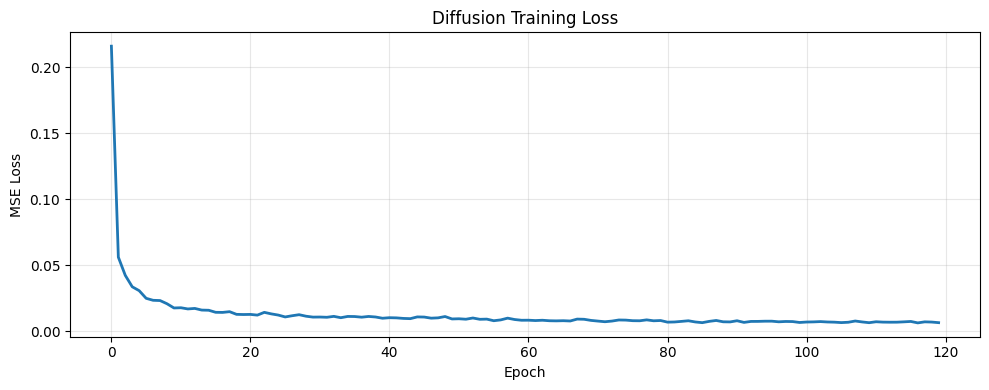

In [16]:
# === CELL 11: Plot Training Loss ===

plt.figure(figsize=(10, 4))
plt.plot(history, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Diffusion Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

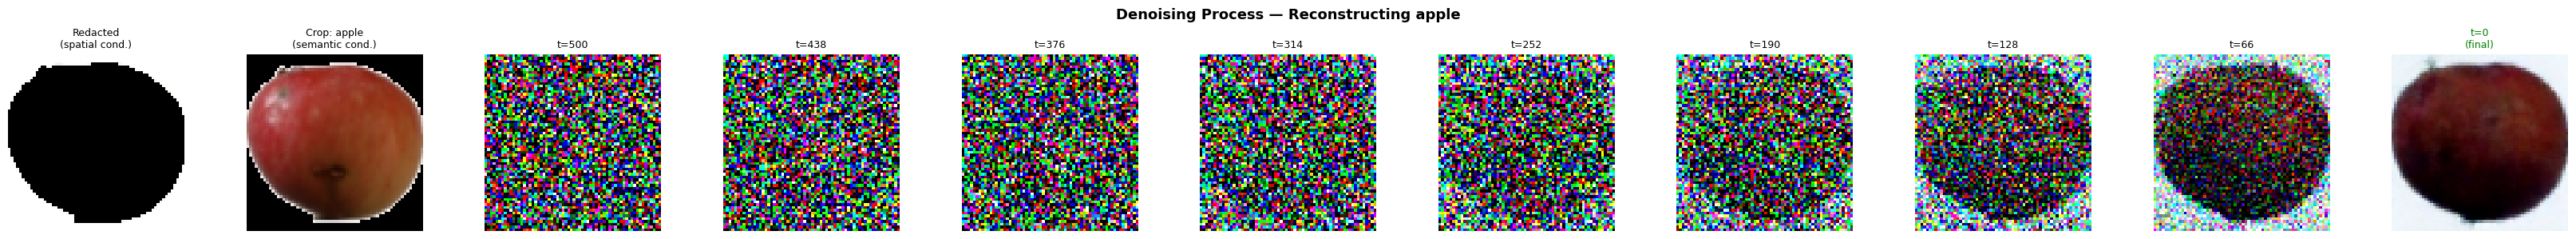

In [17]:
# === CELL 12: Visualize Denoising Process ===
@torch.no_grad()
def visualize_denoising(unet, fruit_encoder, scheduler, test_loader, device, n_steps=8):
    """
    Show the step-by-step denoising process:
    pure noise → ... → final generated image
    """
    unet.eval()
    fruit_encoder.eval()

    images, labels = next(iter(test_loader))
    img = images[0:1].to(device)
    label = labels[0].item()

    masks, crops, redacted = create_mask_and_crop_batch(img)

    # Generate with intermediate snapshots
    result, intermediates = scheduler.sample(
        unet, fruit_encoder, crops, redacted, masks,
        return_intermediates=True, intermediate_steps=n_steps
    )

    # Plot
    n = len(intermediates)
    fig, axes = plt.subplots(1, n + 2, figsize=(3 * (n + 2), 3))

    # Show the conditioning inputs first
    axes[0].imshow(redacted[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0].set_title('Redacted\n(spatial cond.)', fontsize=9)
    axes[0].axis('off')

    axes[1].imshow(crops[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1].set_title(f'Crop: {CLASS_NAMES[label]}\n(semantic cond.)', fontsize=9)
    axes[1].axis('off')

    # Show denoising steps
    for i, inter in enumerate(intermediates):
        axes[i + 2].imshow(inter[0].permute(1, 2, 0).clamp(0, 1).numpy())
        step_num = scheduler.num_timesteps - i * (scheduler.num_timesteps // n_steps)
        axes[i + 2].set_title(f't={step_num}', fontsize=9)
        axes[i + 2].axis('off')

    axes[-1].set_title('t=0\n(final)', fontsize=9, color='green')

    plt.suptitle(f'Denoising Process — Reconstructing {CLASS_NAMES[label]}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_denoising(unet, fruit_encoder, scheduler, test_loader, device)

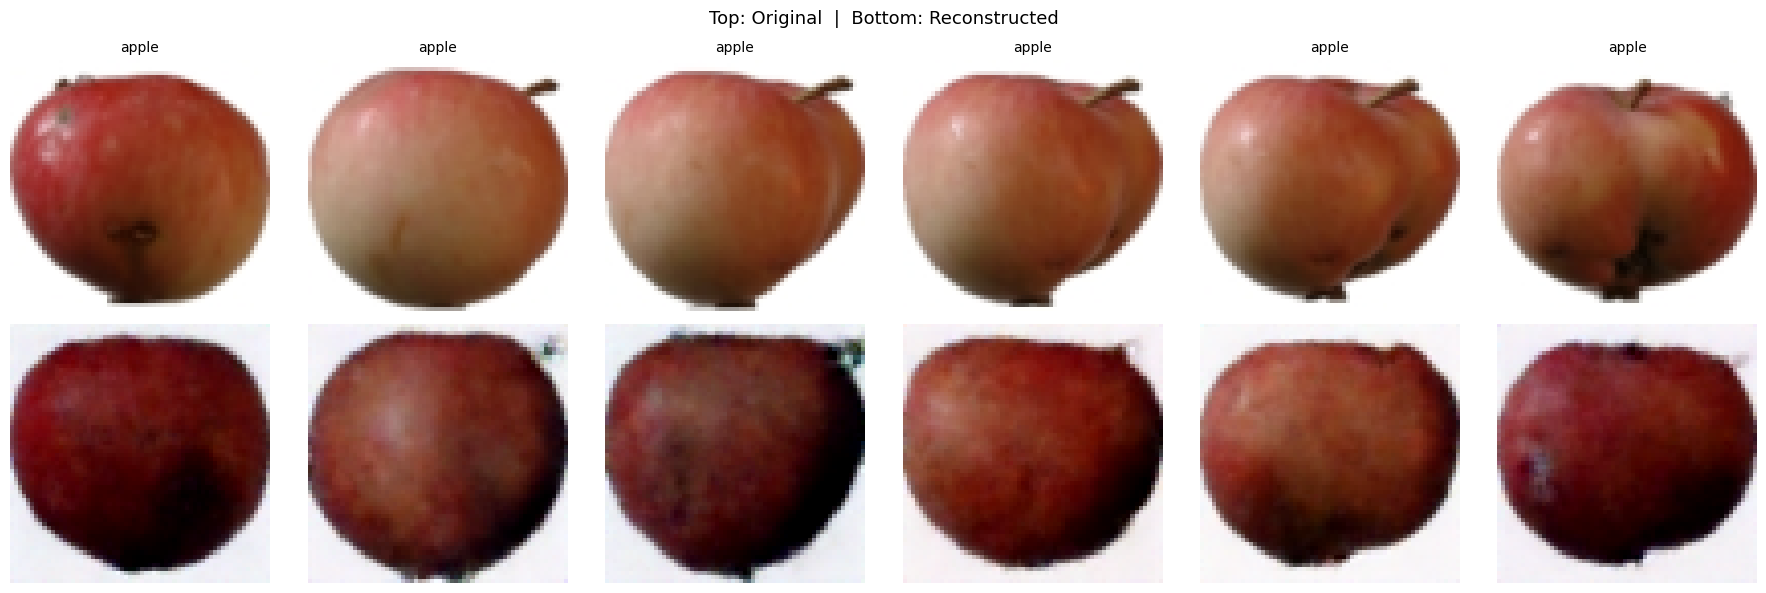

In [18]:
# === CELL 13: Reconstruction — Encode & Regenerate Same Fruit ===

@torch.no_grad()
def show_reconstructions(unet, fruit_encoder, scheduler, test_loader, device, n=6):
    """
    Reconstruct test images: use each image's own crop as conditioning.
    Shows how well the model has learned each fruit type.
    """
    unet.eval()
    fruit_encoder.eval()

    images, labels = next(iter(test_loader))
    images = images[:n].to(device)

    masks, crops, redacted = create_mask_and_crop_batch(images)
    results = scheduler.sample(unet, fruit_encoder, crops, redacted, masks)

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    fig.suptitle('Top: Original  |  Bottom: Reconstructed', fontsize=13)

    for i in range(n):
        axes[0, i].imshow(images[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[0, i].set_title(CLASS_NAMES[labels[i].item()], fontsize=10)
        axes[0, i].axis('off')

        axes[1, i].imshow(results[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

show_reconstructions(unet, fruit_encoder, scheduler, test_loader, device)

In [19]:
# find_samples_per_class imported from utils

/tmp/ipykernel_22280/3238934896.py:63: UserWarning: Glyph 127818 (\N{TANGERINE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22280/3238934896.py:63: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127818 (\N{TANGERINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


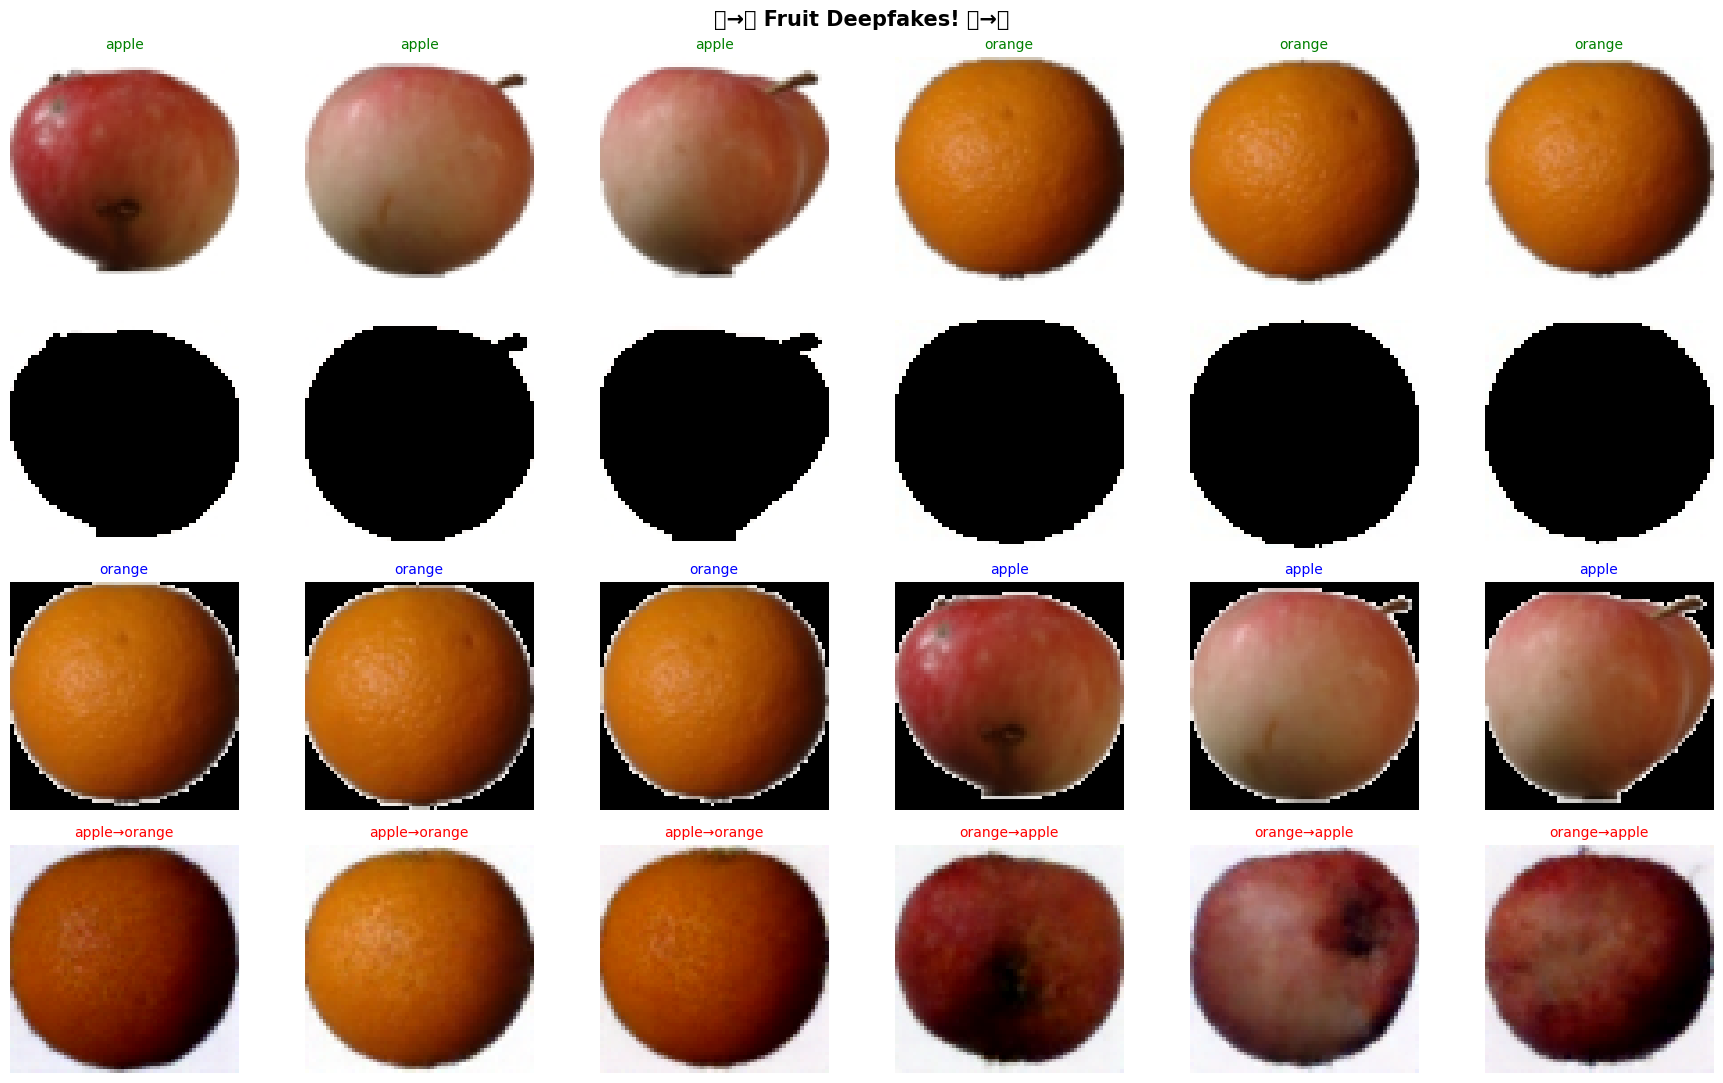

In [20]:
# === CELL 14: DEEPFAKE — Swap the Fruit! ===

@torch.no_grad()
def deepfake_diffusion(unet, fruit_encoder, scheduler, test_loader, device, n=6):
    """
    The deepfake trick:
    - Take an apple image → extract background
    - Condition on an ORANGE embedding
    - Diffusion fills the hole with an orange

    Shows: original | redacted background | source fruit crop | deepfake result
    """
    unet.eval()
    fruit_encoder.eval()

    samples = find_samples_per_class(test_loader, train_dataset.class_to_idx, n_per_class=n//2)
    apple_class = train_dataset.class_to_idx['apple']
    orange_class = train_dataset.class_to_idx['orange']

    apple_imgs = samples[apple_class]
    orange_imgs = samples[orange_class]

    # Targets: apples then oranges. Sources (opposite): oranges then apples.
    n_each = min(n // 2, len(apple_imgs), len(orange_imgs))
    target_images = torch.cat([apple_imgs[:n_each], orange_imgs[:n_each]]).to(device)
    target_labels_list = [apple_class] * n_each + [orange_class] * n_each

    source_images = torch.cat([orange_imgs[:n_each], apple_imgs[:n_each]]).to(device)
    source_labels_list = [orange_class] * n_each + [apple_class] * n_each

    masks, _, redacted = create_mask_and_crop_batch(target_images)
    _, source_crops, _ = create_mask_and_crop_batch(source_images)

    results = scheduler.sample(unet, fruit_encoder, source_crops, redacted, masks)

    # Visualize
    actual_n = len(target_labels_list)
    fig, axes = plt.subplots(4, actual_n, figsize=(3 * actual_n, 11))
    row_labels = ['Original', 'Redacted\n(background)', 'Source fruit\n(conditioning)', 'DEEPFAKE']

    for i in range(actual_n):
        axes[0, i].imshow(target_images[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[0, i].set_title(CLASS_NAMES[target_labels_list[i]], fontsize=10, color='green')

        axes[1, i].imshow(redacted[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())

        axes[2, i].imshow(source_crops[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[2, i].set_title(CLASS_NAMES[source_labels_list[i]], fontsize=10, color='blue')

        axes[3, i].imshow(results[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[3, i].set_title(
            f'{CLASS_NAMES[target_labels_list[i]]}→{CLASS_NAMES[source_labels_list[i]]}',
            fontsize=10, color='red'
        )

        for row in range(4):
            axes[row, i].axis('off')

    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=11, rotation=0, labelpad=80, va='center')

    plt.suptitle('🍊→🍎 Fruit Deepfakes! 🍎→🍊', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

deepfake_diffusion(unet, fruit_encoder, scheduler, test_loader, device)

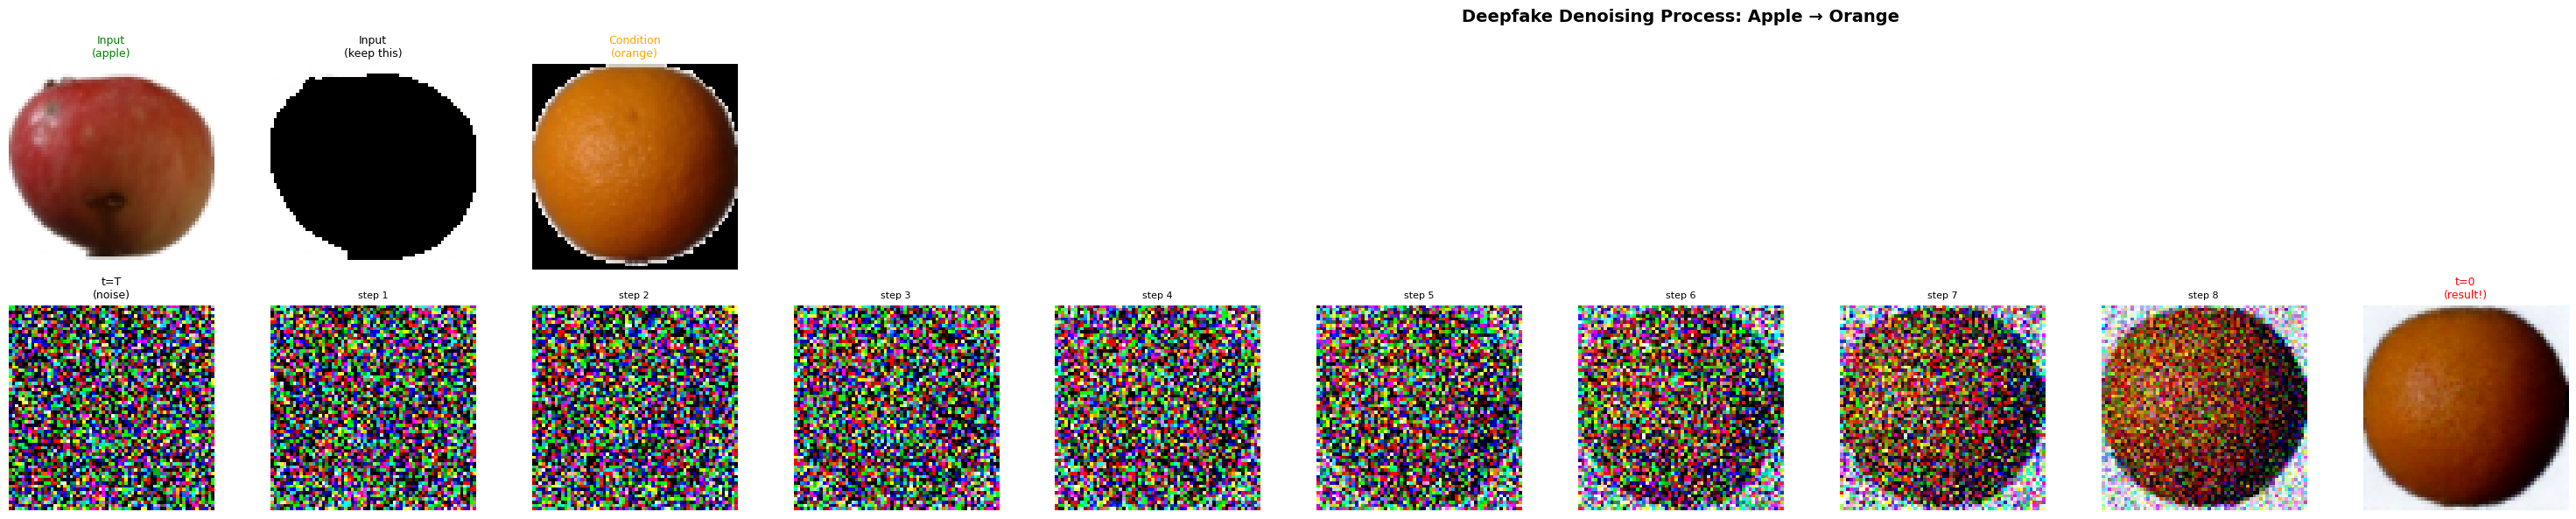

In [21]:
# === CELL 15: Visualize Deepfake Denoising Step-by-Step ===

@torch.no_grad()
def visualize_deepfake_process(unet, fruit_encoder, scheduler, test_loader,
                                device, n_steps=10):
    """
    Show the full deepfake process step by step:
    pure noise → gradually becomes the swapped fruit
    """
    unet.eval()
    fruit_encoder.eval()

    samples = find_samples_per_class(test_loader, train_dataset.class_to_idx, n_per_class=1)
    apple_class = train_dataset.class_to_idx['apple']
    orange_class = train_dataset.class_to_idx['orange']

    if apple_class not in samples or orange_class not in samples:
        print("ERROR: dataset doesn't contain both classes.")
        return

    target_img = samples[apple_class][:1].to(device)
    source_img = samples[orange_class][:1].to(device)

    masks_t, _, redacted_t = create_mask_and_crop_batch(target_img)
    _, source_crop, _ = create_mask_and_crop_batch(source_img)

    result, intermediates = scheduler.sample(
        unet, fruit_encoder, source_crop, redacted_t, masks_t,
        return_intermediates=True, intermediate_steps=n_steps
    )

    # Plot
    fig, axes = plt.subplots(2, n_steps + 3, figsize=(3 * (n_steps + 3), 6))

    # Row 1: the setup
    axes[0, 0].imshow(target_img[0].cpu().permute(1, 2, 0).numpy())
    axes[0, 0].set_title('Input\n(apple)', fontsize=9, color='green')
    axes[0, 1].imshow(redacted_t[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, 1].set_title('Input\n(keep this)', fontsize=9)
    axes[0, 2].imshow(source_crop[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, 2].set_title('Condition\n(orange)', fontsize=9, color='orange')

    for i in range(n_steps + 3):
        axes[0, i].axis('off')
        if i >= 3:
            axes[0, i].set_visible(False)

    # Row 2: denoising progression
    for i, inter in enumerate(intermediates):
        axes[1, i].imshow(inter[0].permute(1, 2, 0).clamp(0, 1).numpy())
        if i == 0:
            axes[1, i].set_title('t=T\n(noise)', fontsize=9)
        elif i == len(intermediates) - 1:
            axes[1, i].set_title('t=0\n(result!)', fontsize=9, color='red')
        else:
            axes[1, i].set_title(f'step {i}', fontsize=8)
        axes[1, i].axis('off')

    # Hide unused axes in row 2
    for i in range(len(intermediates), n_steps + 3):
        axes[1, i].set_visible(False)

    plt.suptitle('Deepfake Denoising Process: Apple → Orange',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_deepfake_process(unet, fruit_encoder, scheduler, test_loader, device)

In [22]:
# === CELL 16: Save Models ===

def save_checkpoint(unet, fruit_encoder, history, filename='diffusion_checkpoint.pt'):
    torch.save({
        'unet_state': unet.state_dict(),
        'encoder_state': fruit_encoder.state_dict(),
        'history': history,
        'config': {
            'img_size': IMG_SIZE,
            'embed_dim': EMBED_DIM,
            'base_channels': BASE_CHANNELS,
            'num_timesteps': NUM_TIMESTEPS,
        }
    }, filename)
    print(f"Checkpoint saved to {filename}")

save_checkpoint(unet, fruit_encoder, history)

Checkpoint saved to diffusion_checkpoint.pt


In [ ]:
# === CELL 17: Generate Deepfake Images for Discriminator Training ===

import zipfile
from PIL import Image
from io import BytesIO

N_FAKES = 100

@torch.no_grad()
def generate_deepfakes_for_discriminator(unet, fruit_encoder, scheduler,
                                          loader, class_to_idx, device, n_fakes=N_FAKES):
    """
    Generate n_fakes deepfake images by swapping fruit conditioning.
    Returns a list of (PIL.Image, index) tuples.
    """
    unet.eval()
    fruit_encoder.eval()

    apple_idx = class_to_idx['apple']
    orange_idx = class_to_idx['orange']

    # Collect source crops per class for conditioning
    source_crops = {apple_idx: [], orange_idx: []}
    for images, labels in loader:
        for cls_idx in [apple_idx, orange_idx]:
            if len(source_crops[cls_idx]) >= 20:
                continue
            cls_mask = labels == cls_idx
            if cls_mask.any():
                cls_imgs = images[cls_mask]
                _, crops, _ = create_mask_and_crop_batch(cls_imgs)
                source_crops[cls_idx].extend(crops)
        if all(len(v) >= 20 for v in source_crops.values()):
            break
    for k in source_crops:
        source_crops[k] = torch.stack(source_crops[k][:20])

    fake_pil_images = []
    generated = 0

    for images, labels in loader:
        if generated >= n_fakes:
            break
        images = images.to(device)

        for i in range(len(images)):
            if generated >= n_fakes:
                break

            img = images[i:i+1]
            lbl = labels[i].item()
            opposite_idx = orange_idx if lbl == apple_idx else apple_idx

            masks_t, _, redacted_t = create_mask_and_crop_batch(img)
            src_idx = random.randint(0, len(source_crops[opposite_idx]) - 1)
            source_crop = source_crops[opposite_idx][src_idx:src_idx+1].to(device)

            fake = scheduler.sample(unet, fruit_encoder, source_crop, redacted_t, masks_t)
            fake = fake.clamp(0, 1)

            # Convert to PIL
            fake_np = (fake[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            fake_pil_images.append(Image.fromarray(fake_np))
            generated += 1

            if generated % 25 == 0:
                print(f"  Generated {generated}/{n_fakes} fakes...")

    return fake_pil_images


print(f"Generating {N_FAKES} deepfake images...")
fake_pil_images = generate_deepfakes_for_discriminator(
    unet, fruit_encoder, scheduler, train_loader,
    train_dataset.class_to_idx, device, N_FAKES
)

# Save as zip
zip_path = 'deepfake_imgs.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for i, img in enumerate(fake_pil_images):
        buf = BytesIO()
        img.save(buf, format='PNG')
        zf.writestr(f'deepfake_imgs/fake_{i:04d}.png', buf.getvalue())

print(f"Saved {len(fake_pil_images)} images to {zip_path}")

# Download in Colab
try:
    from google.colab import files
    files.download(zip_path)
    print("Download started!")
except ImportError:
    print(f"Not running in Colab — zip saved locally at {zip_path}")